
# IT Service Ticket Classification — GenAI + RAG + Agents

Projeto para o desafio técnico **DHAUZ**.

Este notebook implementa três abordagens:

1. **Baseline clássico**
   - TF‑IDF + Logistic Regression

2. **Transformer**
   - DistilBERT fine‑tuned

3. **RAG + LLM**
   - ChromaDB vector store
   - Semantic RAG (retrieve only predicted class)
   - LangChain Agent

Pipeline principal:

ticket → DistilBERT class prediction → retrieve tickets of predicted class → LLM → JSON


## 1. Instalação de dependências

In [ ]:
!pip install -q kagglehub
!pip install -q transformers datasets accelerate evaluate
!pip install -q sentence-transformers
!pip install -q chromadb
!pip install -q langchain langchain-community
!pip install -q gradio nltk seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.6/21.6 MB 40.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 45.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.1/72.1 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.6/231.6 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 3.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently t

In [1]:
!pip install -U langchain langchain-core langchain-community langchain-ollama langchain-chroma chromadb langchain-classic langchain-huggingface

## 2. Imports

In [2]:
import os
import json
import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, cohen_kappa_score


## 3. Download dataset

In [3]:
import kagglehub

path = kagglehub.dataset_download(
    "adisongoh/it-service-ticket-classification-dataset"
)

print("Dataset path:", path)

df = pd.read_csv(os.path.join(path,"all_tickets_processed_improved_v3.csv"))

df = df.rename(columns={
    "Document":"text",
    "Topic_group":"class"
})

df.head()


100%|██████████| 3.45M/3.45M [00:01<00:00, 2.40MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/adisongoh/it-service-ticket-classification-dataset/versions/1


,text,class
0,connection with icon icon dear please setup ic...,Hardware
1,work experience user work experience user hi w...,Access
2,requesting for meeting requesting meeting hi p...,Hardware
3,reset passwords for external accounts re expir...,Access
4,mail verification warning hi has got attached ...,Miscellaneous


## 4. Exploração

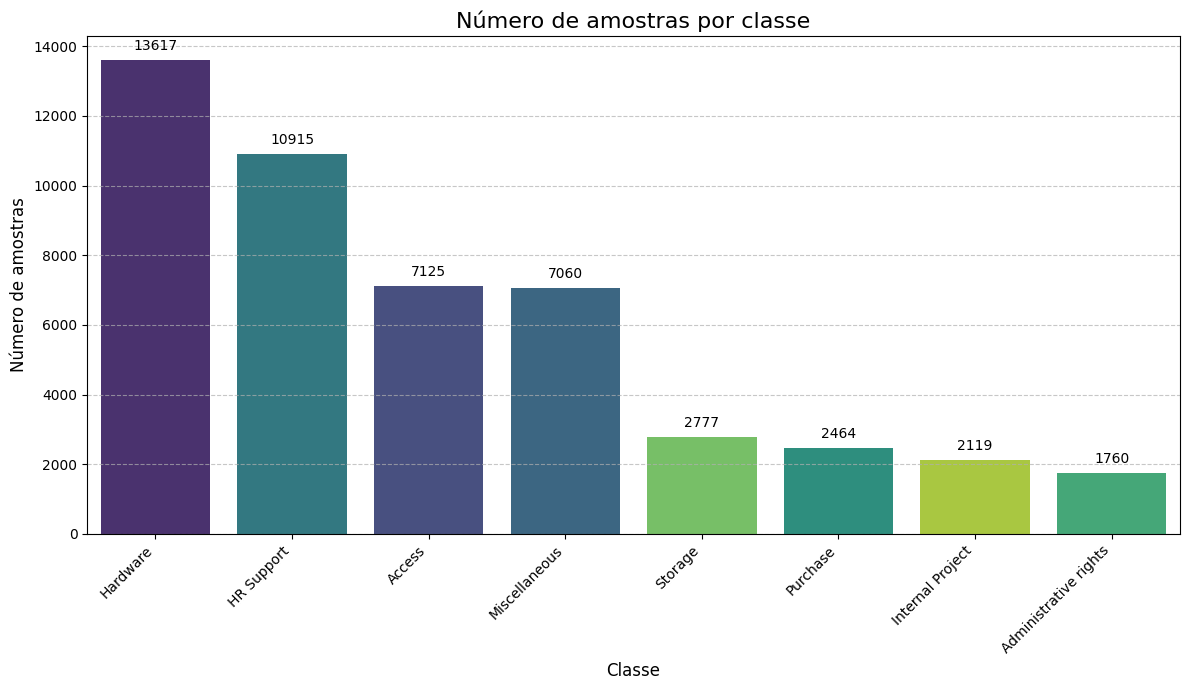

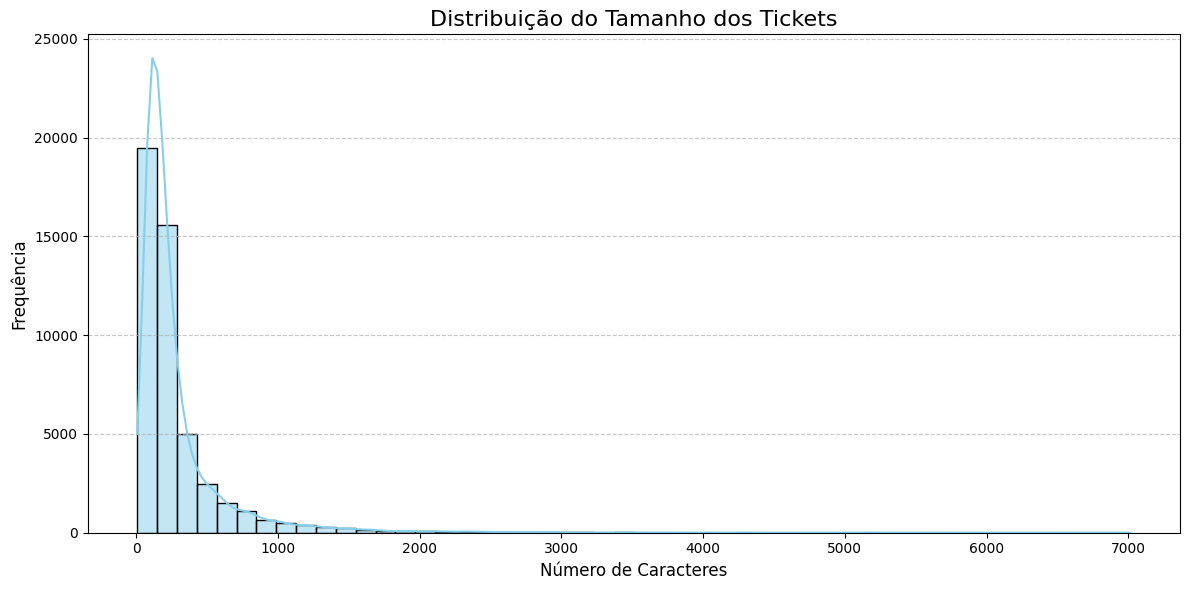

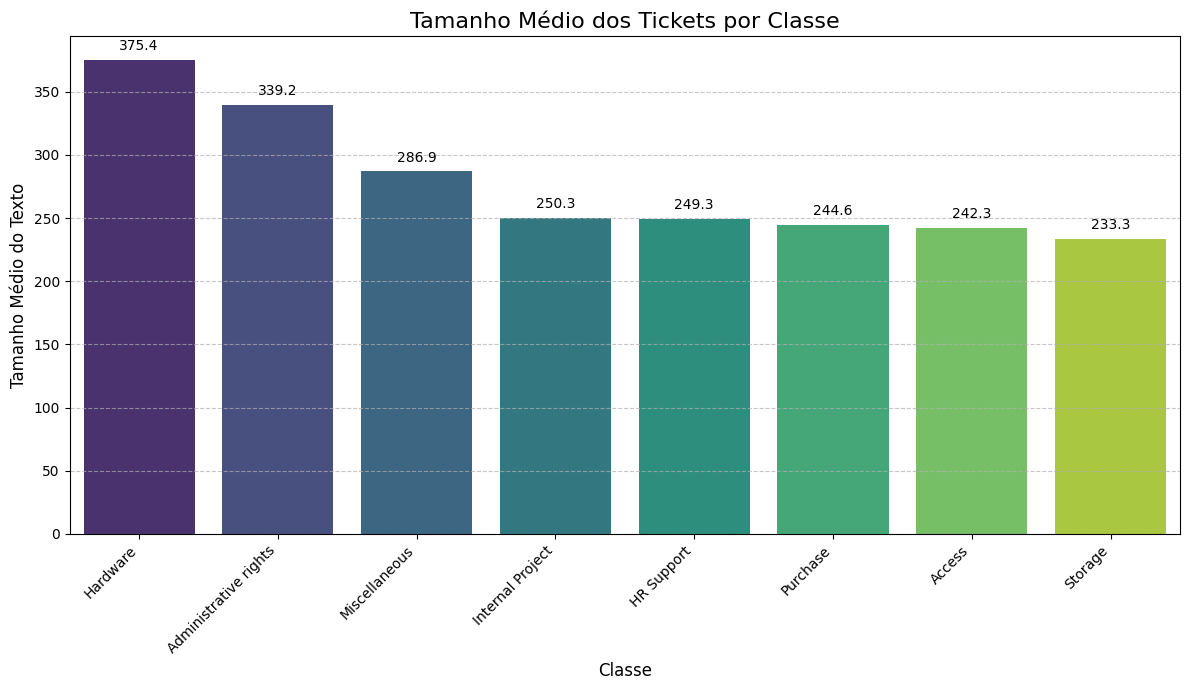

In [4]:
order = df['class'].value_counts(ascending=False).index
plt.figure(figsize=(12,7))

sns.countplot(x='class', data=df, order=order, palette='viridis', hue='class', legend=False)
plt.xticks(rotation=45, ha='right')
plt.title('Número de amostras por classe', fontsize=16)
plt.xlabel('Classe', fontsize=12)
plt.ylabel('Número de amostras', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for p in plt.gca().patches:
    plt.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontsize=10)
plt.tight_layout()
plt.show()

"""### Distribuição do Tamanho dos Tickets"""

df['text_length'] = df['text'].apply(len)

plt.figure(figsize=(12, 6))
sns.histplot(df['text_length'], bins=50, kde=True, color='skyblue')
plt.title('Distribuição do Tamanho dos Tickets', fontsize=16)
plt.xlabel('Número de Caracteres', fontsize=12)
plt.ylabel('Frequência', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

"""### Tamanho Médio dos Tickets por Classe"""

avg_length_per_class = df.groupby('class')['text_length'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x=avg_length_per_class.index, y=avg_length_per_class.values, palette='viridis', hue=avg_length_per_class.index, legend=False)
plt.xticks(rotation=45, ha='right')
plt.title('Tamanho Médio dos Tickets por Classe', fontsize=16)
plt.xlabel('Classe', fontsize=12)
plt.ylabel('Tamanho Médio do Texto', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for p in plt.gca().patches:
    plt.annotate(f'{p.get_height():.1f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontsize=10)
plt.tight_layout()
plt.show()


## 5. Split dataset

In [5]:
train, val = train_test_split(
    df,
    test_size=0.2,
    stratify=df["class"],
    random_state=42
)

test = val.sample(200,random_state=42)

print(len(train),len(val),len(test))


38269 9568 200


## 6. TF‑IDF + Logistic Regression

In [ ]:
tfidf = TfidfVectorizer(max_features=10000,stop_words="english")

X_train = tfidf.fit_transform(train["text"])
X_val = tfidf.transform(val["text"])
X_test = tfidf.transform(test["text"])

y_train = train["class"]
y_val = val["class"]
y_test = test["class"]

clf = LogisticRegression(max_iter=1000,class_weight="balanced")
clf.fit(X_train,y_train)

val_pred = clf.predict(X_val)

print(classification_report(y_val,val_pred))
print("Cohen Kappa:",cohen_kappa_score(y_val,val_pred))


                       precision    recall  f1-score   support

               Access       0.89      0.88      0.89      1425
Administrative rights       0.68      0.87      0.76       352
           HR Support       0.88      0.82      0.85      2183
             Hardware       0.85      0.79      0.82      2724
     Internal Project       0.79      0.94      0.85       424
        Miscellaneous       0.78      0.87      0.82      1412
             Purchase       0.91      0.91      0.91       493
              Storage       0.84      0.93      0.88       555

             accuracy                           0.84      9568
            macro avg       0.83      0.87      0.85      9568
         weighted avg       0.85      0.84      0.84      9568

Cohen Kappa: 0.8101981862697633


In [ ]:
test_pred = clf.predict(X_test)

print(classification_report(y_test,test_pred))
print("Cohen Kappa:",cohen_kappa_score(y_test,test_pred))

## 7. DistilBERT

In [6]:
classes = sorted(train["class"].unique())
class_to_idx = {c:i for i,c in enumerate(classes)}

In [7]:
from transformers import DistilBertTokenizerFast
from transformers import DistilBertForSequenceClassification
from transformers import Trainer,TrainingArguments
from datasets import Dataset

train["label"] = train["class"].map(class_to_idx)
val["label"] = val["class"].map(class_to_idx)

train_ds = Dataset.from_pandas(train[["text","label"]])
val_ds = Dataset.from_pandas(val[["text","label"]])

tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

def tokenize(example):
    return tokenizer(example["text"],padding="max_length",truncation=True, max_length=256)

train_ds = train_ds.map(tokenize,batched=True)
val_ds = val_ds.map(tokenize,batched=True)

train_ds.set_format("torch",columns=["input_ids","attention_mask","label"])
val_ds.set_format("torch",columns=["input_ids","attention_mask","label"])


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/38269 [00:00<?, ? examples/s]

Map:   0%|          | 0/9568 [00:00<?, ? examples/s]

In [8]:
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    # "./results/checkpoint-2392",
    num_labels=len(classes)
)


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [9]:
training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=32,
    num_train_epochs=2,
    # report_to="none",
    logging_steps=100,
    fp16=True,
)

In [10]:
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):

    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average="macro")

    return {
        "accuracy": acc,
        "f1": f1
    }

In [11]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics
)

trainer.train()

Step,Training Loss
100,1.477353
200,0.783923
300,0.596218
400,0.583685
500,0.508201
600,0.496274
700,0.472729
800,0.453523
900,0.431049
1000,0.416718


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2392, training_loss=0.4289153347844663, metrics={'train_runtime': 541.0479, 'train_samples_per_second': 141.463, 'train_steps_per_second': 4.421, 'total_flos': 5069937311932416.0, 'train_loss': 0.4289153347844663, 'epoch': 2.0})

In [12]:
test['label'] = test['class'].map(class_to_idx)
test_ds = Dataset.from_pandas(test[["text","label"]])
test_ds = test_ds.map(tokenize,batched=True)

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

In [13]:
val_pred_bert = trainer.predict(val_ds)
val_pred_bert = np.argmax(val_pred_bert.predictions, axis=1)

print(classification_report(val["label"],val_pred_bert))
print("Cohen Kappa:",cohen_kappa_score(val["label"],val_pred_bert))


              precision    recall  f1-score   support

           0       0.89      0.93      0.91      1425
           1       0.86      0.76      0.81       352
           2       0.89      0.90      0.89      2183
           3       0.87      0.87      0.87      2724
           4       0.91      0.88      0.89       424
           5       0.86      0.85      0.86      1412
           6       0.94      0.90      0.92       493
           7       0.91      0.90      0.90       555

    accuracy                           0.88      9568
   macro avg       0.89      0.87      0.88      9568
weighted avg       0.88      0.88      0.88      9568

Cohen Kappa: 0.8562935753289119


In [14]:
test_pred_bert = trainer.predict(test_ds)
test_pred_bert = np.argmax(test_pred_bert.predictions, axis=1)

print(classification_report(test["label"],test_pred_bert))
print("Cohen Kappa:",cohen_kappa_score(test["label"],test_pred_bert))

              precision    recall  f1-score   support

           0       0.94      0.97      0.95        32
           1       0.83      0.71      0.77         7
           2       0.87      0.88      0.88        52
           3       0.88      0.86      0.87        51
           4       0.86      1.00      0.92        12
           5       0.88      0.81      0.84        26
           6       1.00      0.88      0.93         8
           7       0.85      0.92      0.88        12

    accuracy                           0.89       200
   macro avg       0.89      0.88      0.88       200
weighted avg       0.89      0.89      0.88       200

Cohen Kappa: 0.8588610702012763


## 8. Preprocessamento texto (RAG)

In [15]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download("stopwords")
nltk.download("wordnet")

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess(text):

    text = text.lower()
    text = re.sub(r"http\S+","",text)
    text = text.translate(str.maketrans("","",string.punctuation))

    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return " ".join(tokens)

train["clean_text"] = train["text"].apply(preprocess)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


## 9. Chroma Vector Store

In [16]:
from langchain_core.documents import Document
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import Chroma

docs = []

for _,row in train.iterrows():

    docs.append(
        Document(
            page_content=row["text"],
            metadata={
                "class":row["class"],
                "original_text":row["text"]
            }
        )
    )

embedding_model = HuggingFaceEmbeddings(
    model_name="all-MiniLM-L6-v2"
)

vector_db = Chroma.from_documents(
    docs,
    embedding_model,
    persist_directory="./chroma_db"
)


/tmp/ipykernel_1980/2466778428.py:19: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embedding_model = HuggingFaceEmbeddings(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

## 10. Semantic RAG Retriever

In [33]:
import torch
import numpy as np


def bert_class_scores_batch(tickets):

    # garante lista
    if isinstance(tickets, str):
        tickets = [tickets]

    inputs = tokenizer(
        tickets,
        return_tensors="pt",
        truncation=True,
        padding=True
    )

    inputs = {k: v.to("cuda") for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits
    probs = torch.softmax(logits, dim=1).cpu().numpy()

    scores = []

    for prob in probs:
        scores.append(dict(zip(classes, prob)))

    return scores


def top_k_classes_batch(tickets, k=3):

    if isinstance(tickets, str):
        tickets = [tickets]

    scores_batch = bert_class_scores_batch(tickets)

    top_classes = []

    for scores in scores_batch:

        sorted_classes = sorted(
            scores.items(),
            key=lambda x: x[1],
            reverse=True
        )

        top_classes.append([c[0] for c in sorted_classes[:k]])

    return top_classes


def retrieve_examples_batch(tickets, k=3):

    # garante lista
    single_input = False
    if isinstance(tickets, str):
        tickets = [tickets]
        single_input = True

    top_classes = top_k_classes_batch(tickets, k)

    retrieved_examples = []

    for ticket, candidate_classes in zip(tickets, top_classes):

        examples = []

        for cls in candidate_classes:

            docs = vector_db.similarity_search(
                ticket,
                k=5,
                filter={"class": cls}
            )

            # garantir lista flat
            if isinstance(docs, list):
                examples.extend(docs)
            else:
                examples.append(docs)

        examples = sorted(
            examples,
            key=lambda d: d.metadata.get("score", 0),
            reverse=True
        )

        retrieved_examples.append(examples[:k])

    # se recebeu só um ticket, retorna só a lista de docs
    if single_input:
        return retrieved_examples[0]

    return retrieved_examples


def bert_topk_with_confidence(tickets, k=3):

    if isinstance(tickets, str):
        tickets = [tickets]

    scores_batch = bert_class_scores_batch(tickets)

    results = []

    for scores in scores_batch:

        sorted_classes = sorted(
            scores.items(),
            key=lambda x: x[1],
            reverse=True
        )

        top_classes = [c[0] for c in sorted_classes[:k]]
        top_probs = [c[1] for c in sorted_classes[:k]]

        results.append({
            "top_classes": top_classes,
            "top_probs": top_probs,
            "confidence": top_probs[0]
        })

    return results

## 11. LLM (Ollama)

In [18]:
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
import torch

# model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
model_name = "Qwen/Qwen2.5-3B-Instruct"

tokenizer_llm = AutoTokenizer.from_pretrained(model_name, padding_side='left')

model_llm = AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype=torch.float16,
    device_map="auto"
)


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

In [19]:
from transformers import GenerationConfig

generation_config_ = GenerationConfig(
    do_sample=False,
    max_new_tokens=64,
    repetition_penalty=1.1
)

pipe = pipeline(
    "text-generation",
    model=model_llm,
    tokenizer=tokenizer_llm,
    config=generation_config_,
    return_full_text=False,
)

In [ ]:
# from langchain_huggingface import HuggingFacePipeline, ChatHuggingFace

# llm_pipeline = HuggingFacePipeline(pipeline=pipe)

# llm = ChatHuggingFace(
#     llm=llm_pipeline
# )

In [ ]:
torch.cuda.empty_cache()

## 12. RAG Classifier

In [20]:
import json
import re

def extract_json(text):

    matches = re.findall(r'\{[^{}]*\}', text)

    for m in matches:
        try:
            data = json.loads(m)

            if "class" in data and "justification" in data:
                return data

        except:
            continue

    return None

In [21]:
from langchain_core.messages import HumanMessage, SystemMessage

def rag_classifier_batch(tickets):
    prompts = []

    for ticket in tickets:

        retrieved = retrieve_examples_batch(ticket, k=3)
        examples = ""

        for doc in retrieved:

            examples += f"""
Ticket: {doc.metadata['original_text']}
Class: {doc.metadata['class']}
"""

        user_prompt = f"""Classify the IT support ticket.

Ticket:
{ticket}

Choose EXACTLY ONE category from:
{", ".join(classes)}

Return ONLY this JSON and NOTHING ELSE:

{{"class": "<category>", "justification": "<short reason>"}}
"""

        messages = [
            SystemMessage(
                content=f"""You are an AI assistant specialized in IT support ticket classification.

ONLY Possible categories:
{", ".join(classes)}

Examples:
{examples}
"""
            ),
            HumanMessage(content=user_prompt)
        ]

        prompt = tokenizer_llm.apply_chat_template(
            [
                {"role": "system", "content": messages[0].content},
                {"role": "user", "content": messages[1].content}
            ],
            tokenize=False,
            add_generation_prompt=True
        )

        prompts.append(prompt)

    outputs = pipe(
            prompts,
            batch_size=1,
            return_full_text=False
        )

    results = []

    for out in outputs:

        if isinstance(out, list):
            generated = out[0]["generated_text"]
        else:
            generated = out["generated_text"]

        parsed = extract_json(generated)

        if parsed is None or parsed["class"] not in classes:
            parsed = {
                "class": "Miscellaneous",
                "justification": "Invalid model output"
            }
        results.append(parsed)

    return results

In [34]:
from langchain_core.messages import HumanMessage, SystemMessage

def rag_classifier_batch_hybrid(tickets, candidate_classes_batch):

    prompts = []

    for ticket, candidate_classes in zip(tickets, candidate_classes_batch):

        retrieved = retrieve_examples_batch(ticket, k=3)

        examples = ""
        for doc in retrieved:
            examples += f"""
Ticket: {doc.metadata['original_text']}
Class: {doc.metadata['class']}
"""

        user_prompt = f"""Classify the IT support ticket.

Ticket:
{ticket}

Choose EXACTLY ONE category from:

1. {candidate_classes[0]}
2. {candidate_classes[1]}
3. {candidate_classes[2]}

Return ONLY this JSON:

{{"class": "<category>", "justification": "<short reason>"}}
"""

        messages = [
            SystemMessage(
                content=f"""You are an AI assistant specialized in IT support ticket classification.

Possible categories:
{", ".join(candidate_classes)}

Examples:
{examples}
"""
            ),
            HumanMessage(content=user_prompt)
        ]

        prompt = tokenizer_llm.apply_chat_template(
            [
                {"role": "system", "content": messages[0].content},
                {"role": "user", "content": messages[1].content}
            ],
            tokenize=False,
            add_generation_prompt=True
        )

        prompts.append(prompt)

    outputs = pipe(
        prompts,
        batch_size=1,
        return_full_text=False
    )

    results = []

    for out in outputs:

        if isinstance(out, list):
            generated = out[0]["generated_text"]
        else:
            generated = out["generated_text"]

        parsed = extract_json(generated)

        if parsed is None:
            parsed = {
                "class": "Miscellaneous",
                "justification": "Invalid model output"
            }

        results.append(parsed)

    return results

In [35]:
def hybrid_classifier_batch(tickets, threshold=0.9):

    bert_results = bert_topk_with_confidence(tickets)

    final_results = []
    rag_tickets = []
    rag_classes = []
    rag_indices = []

    for i, (ticket, bert_res) in enumerate(zip(tickets, bert_results)):

        confidence = bert_res["confidence"]
        top_classes = bert_res["top_classes"]

        if confidence >= threshold:

            final_results.append({
                "class": top_classes[0],
                "justification": "High confidence DistilBERT prediction"
            })

        else:

            rag_tickets.append(ticket)
            rag_classes.append(top_classes)
            rag_indices.append(i)

            final_results.append(None)

    if len(rag_tickets) > 0:

        rag_outputs = rag_classifier_batch_hybrid(
            rag_tickets,
            rag_classes
        )

        for idx, rag_out in zip(rag_indices, rag_outputs):
            final_results[idx] = rag_out

    return final_results

In [36]:
def rag_predict_batch(batch):

    results = rag_classifier_batch(batch["text"])

    return {
        "prediction": [r["class"] for r in results],
        "justification": [r["justification"] for r in results]
    }

In [37]:
def hybrid_predict_batch(batch):

    results = hybrid_classifier_batch(batch["text"])

    return {
        "prediction": [r["class"] for r in results],
        "justification": [r["justification"] for r in results]
    }

## 13. LangChain Agent

In [ ]:
from langchain.agents import create_agent
from langchain_classic.agents import AgentExecutor
from langchain_core.tools import StructuredTool

tool = StructuredTool.from_function(
    func=rag_classifier_batch,
    name="IT_Ticket_Classifier",
    description="Classify an IT support ticket into predefined categories"
)

tools = [tool]

system_prompt = """
You are an AI assistant specialized in IT support ticket classification.

When a user sends a ticket:
1. Always call the IT_Ticket_Classifier tool
2. Return the JSON result from the tool without modification.
"""

agent = create_agent(
    model=llm,
    tools=tools,
    system_prompt=system_prompt
)

agent_executor = AgentExecutor(
    agent=agent,
    tools=tools,
    verbose=True
)

## 14. Teste do Agent

In [26]:
ticket = "User cannot connect to VPN after password reset"

result = rag_classifier_batch([ticket,'access to oracle and wednesday november pm dear please create please viewer role planner well add level thanks kind regards officer november re approved wednesday november pm hi want please reports kindly approve thanks head november wait re hi level looking how call solution client level approve well own requests each license implication consider skip training how give extracts work part well kind regards officer november wait hi told help budgeting application view onto appreciate lot help available find thank much senior blvd fax subscribe notified about events publications choice please consider environment printing'])

print(result)

Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'class': 'Access', 'justification': 'User needs to reconnect after a password reset, indicating an access issue.'}, {'class': 'Access', 'justification': 'The ticket is requesting access to Oracle and creating a viewer role for a planner, indicating it falls under access management.'}]


In [44]:
hf_test = test_ds.map(
    rag_predict_batch,
    batched=True,
    batch_size=1,
    desc="Running RAG classifier"
)

Running RAG classifier:   0%|          | 0/200 [00:00<?, ? examples/s]

Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

In [38]:
hf_test = test_ds.map(
    hybrid_predict_batch,
    batched=True,
    batch_size=1,
    desc="Running RAG classifier"
)

Running RAG classifier:   0%|          | 0/200 [00:00<?, ? examples/s]

Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

In [45]:
test = test.reset_index(drop=True)

hf_test_df = hf_test.to_pandas().reset_index(drop=True)

test["prediction"] = hf_test_df["prediction"]
test["justification"] = hf_test_df["justification"]

In [46]:
for i, row in test.iterrows():
    if row['justification'] == 'Invalid model output':
        print(i)
        tries = 0
        while tries < 3:
            result = rag_classifier_batch([row['text']])[0]

            if result['justification'] != 'Invalid model output':
                break

            tries += 1
        print(row['class'], result['class'], result['justification'])
        test.at[i, 'prediction'] = result['class']
        test.at[i, 'justification'] = result['justification']

In [47]:
test

,text,class,text_length,label,prediction,justification
0,access to oracle and wednesday november pm dea...,Hardware,627,3,Access,The ticket is requesting access to Oracle and ...
1,users february pm users hi please create users...,Access,81,0,Access,Ticket requests creation of users which falls ...
2,bland update to be made tuesday october pm upd...,Miscellaneous,149,5,HR Support,Contains a request to update a job title which...
3,oracle fusion projects set up please check and...,Internal Project,379,4,Internal Project,The ticket is about setting up and updating Or...
4,new project code as wednesday october pm setup,Internal Project,46,4,Internal Project,The ticket mentions a new project code to be s...
...,...,...,...,...,...,...
195,create template service now for monthly report...,Miscellaneous,612,5,Miscellaneous,The ticket requests creating a template and mo...
196,patch cord friday october pm patch cord hello ...,Hardware,100,3,Hardware,"The ticket mentions a patch cord, which is rel..."
197,deactivation of access cards july deactivation...,Access,114,0,Access,"The ticket is about deactivating access cards,..."
198,cont va se si locked officer ext blvd,Hardware,37,3,Access,"The ticket mentions 'locked officer ext', indi..."


<Axes: >

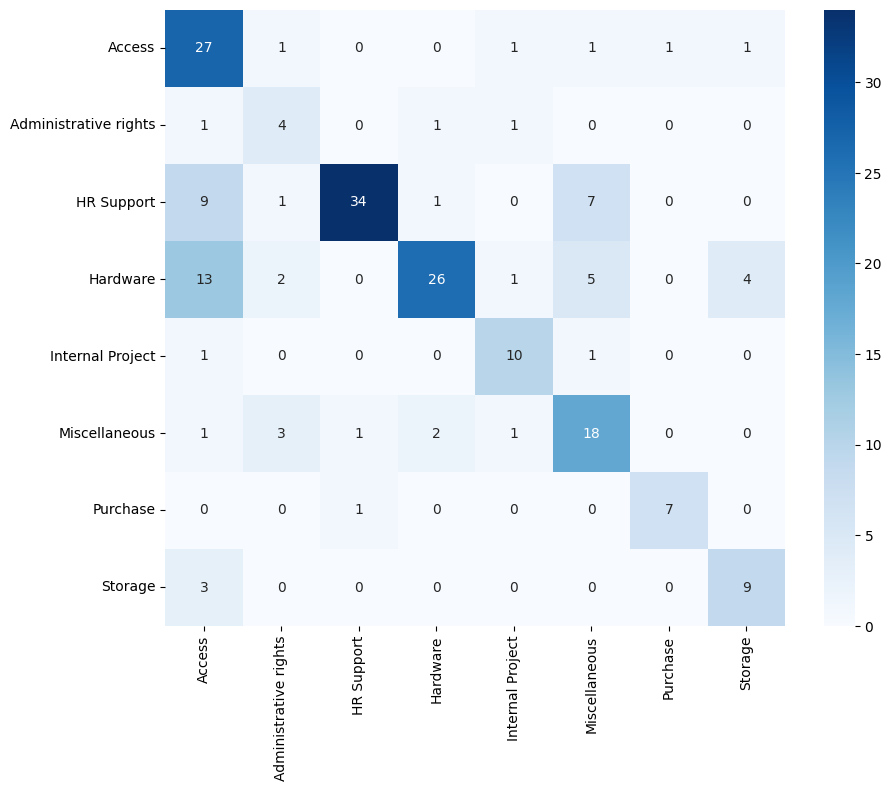

In [48]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(
    test["class"],
    test["prediction"],
    labels=classes
)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

In [49]:
print(
    classification_report(
        test["class"],
        test["prediction"],
        # zero_division=0,
        labels=classes
    )
)

                       precision    recall  f1-score   support

               Access       0.49      0.84      0.62        32
Administrative rights       0.36      0.57      0.44         7
           HR Support       0.94      0.65      0.77        52
             Hardware       0.87      0.51      0.64        51
     Internal Project       0.71      0.83      0.77        12
        Miscellaneous       0.56      0.69      0.62        26
             Purchase       0.88      0.88      0.88         8
              Storage       0.64      0.75      0.69        12

             accuracy                           0.68       200
            macro avg       0.68      0.72      0.68       200
         weighted avg       0.75      0.68      0.68       200



## 15. Interface Gradio

In [58]:
def rag_classifier(ticket):
    result = rag_classifier_batch([ticket])[0]

    return result['class'], result['justification']


In [55]:
def rag_classifier_v2(ticket):
    result = hybrid_classifier_batch([ticket])[0]

    return result['class'], result['justification']


In [59]:
import gradio as gr

demo = gr.Interface(
    fn=rag_classifier,
    inputs=gr.Textbox(
        lines=4,
        label="IT Support Ticket"
    ),
    outputs=[
        gr.Label(label="Predicted Class"),
        gr.Textbox(label="Justification")
    ],
    examples=[
        "User cannot connect to VPN after password reset",
        "Laptop screen broken need replacement",
        "Create account for new employee",
        "Need access to Oracle reports"
    ],
    title="IT Ticket Classifier (RAG)",
    description="Hybrid classifier using DistilBERT + Retrieval + LLM reasoning."
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8e58247afbaf3d8d0d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
